<a href="https://colab.research.google.com/github/NadiiaIvashchuk/Cafe_Sales/blob/main/EDA_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analysis Cafe Sales**

*Cafe Sales - Dirty Data for Cleaning Training*  


**Overview**  
The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.


**File Information**
- File Name: dirty_cafe_sales.csv
- Number of Rows: 10,000
- Number of Columns: 8

| Column Name |	Description	Example | Values |
| ----------- | ------------------- | ------ |
| `Transaction ID`	| A unique identifier for each transaction. Always present and unique |	`TXN_1234567`
| `Item`	| The name of the item purchased. May contain missing or invalid values (e.g., "ERROR") |	`Coffee`, `Sandwich` |
| `Quantity`	| The quantity of the item purchased. May contain missing or invalid values |	`1`, `3`, `UNKNOWN` |
| `Price Per Unit` |	The price of a single unit of the item. May contain missing or invalid values |	`2.00`, `4.00` |
|`Total Spent`	| The total amount spent on the transaction. Calculated as Quantity * Price Per Unit |	`8.00`, `12.00` |
| `Payment Method`	| The method of payment used. May contain missing or invalid values (e.g., `None`, `"UNKNOWN"`) | `Cash`, `Credit Card`
| `Location`	| The location where the transaction occurred. May contain missing or invalid values |	`In-store`, `Takeaway` |
| `Transaction Date`	| The date of the transaction. May contain missing or incorrect values |	`2023-01-01` |


`!pip install numpy pandas matplotlib`


In [296]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [297]:
# File path:
FILE_IN = 'https://raw.githubusercontent.com/NadiiaIvashchuk/Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'
FILE_OUT = 'cafe_sales_clean.csv'

# Dataset loading

In [298]:
df_origin = pd.read_csv(FILE_IN)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [299]:
df = df_origin.copy()

# Primary diagnosis

In [300]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Dataset have:
- 8 columns

In [302]:
print('Data types (raw):\n')
df.dtypes

Data types (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
- Numeric columns (Quantity, Price Per Unit, Total Spent)
- Date columns (Transaction Date)

Missing values:

In [303]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [304]:
print('Unique value')

print("----Item----\n")
display(df['Item'].value_counts(dropna=False))

print("\n----Payment Method----\n")
display(df['Payment Method'].value_counts(dropna=False))

print("\n----Location----\n")
display(df['Location'].value_counts(dropna=False))

Unique value
----Item----



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



----Payment Method----



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



----Location----



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [305]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
display(df.isin(['ERROR', 'UNKNOWN']).any())

mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"\nLines with 'ERROR' or 'UNKNOWN'{mask_error.sum()}")


Find lines with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,False
Item,True
Quantity,True
Price Per Unit,True
Total Spent,True
Payment Method,True
Location,True
Transaction Date,True



Lines with 'ERROR' or 'UNKNOWN'2845


In [306]:
display(df.isin(['ERROR', 'UNKNOWN']).any().value_counts())

,count
True,7
False,1


In [307]:
display(df.isin(['ERROR', 'UNKNOWN']).sum())

,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301


# Data cleaning

- `df_origin` - origin dataset
- `df` - copy origin dataset

In [308]:
print("Rename columns:\n")

df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})
print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


Other variants for rename:

In [309]:
# 1
df.columns.str.lower().str.split()

Index([  ['transaction_id'],             ['item'],         ['quantity'],
         ['price_per_unit'],      ['total_spent'],   ['payment_method'],
               ['location'], ['transaction_date']],
      dtype='object')

In [310]:
# 2
"_".join('  Transaction Date  '.lower().split())

'transaction_date'

In [311]:
# 3
"   Transaction   Date   ".strip().lower().replace(" ", "_")

'transaction___date'

In [312]:
# 4
df.columns.str.lower().str.split()


Index([  ['transaction_id'],             ['item'],         ['quantity'],
         ['price_per_unit'],      ['total_spent'],   ['payment_method'],
               ['location'], ['transaction_date']],
      dtype='object')

In [313]:
# 'ERROR', 'UNKNOWN' -> NaN
df.replace(['ERROR', 'UNKNOWN', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [314]:

# Converting to numeric:
for col in ['quantity', 'price_per_unit', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')


In [315]:
#wenn we change mistakeable a column, we use this command:
#df['transaction_date'] = df_origin['Transaction Date'].copy()

In [316]:

# Converting to date:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df.dtypes
df['transaction_date']

,transaction_date
0,2023-09-08
1,2023-05-16
2,2023-07-19
3,2023-04-27
4,2023-06-11
...,...
9995,2023-08-30
9996,2023-06-02
9997,2023-03-02
9998,2023-12-02


# Theory
`df.dt.strftime('%B')` # full monat name
`df.dt.strftime('%b')` # short monat name
`df.dt.strftime('%A')` # day number


In [317]:
# Extract time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int16')
df['month'] = df['transaction_date'].dt.month.astype('Int8')

#df['month_name'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')
df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int8')

display(df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].dtypes)
df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].head()

,0
transaction_date,datetime64[ns]
year,Int16
month,Int8
month_name,object
weekday,object
week,Int8


,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [318]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = df.loc[mask_recoverable, 'quantity'] * df.loc[mask_recoverable, 'price_per_unit']
# mask_recoverable.sum()
print(f"Restoring total_spent: {mask_recoverable.sum()} (quantity * price)")

Restoring total_spent: 462 (quantity * price)


In [319]:
df['item']

,item
0,Coffee
1,Cake
2,Cookie
3,Salad
4,Coffee
...,...
9995,Coffee
9996,NaN
9997,Coffee
9998,Cookie


In [320]:
# dict of median price
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median().to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_unit: {mask_price.sum()} string(median per item)")

Restoring price_per_unit: 479 string(median per item)


In [321]:
# Шпаргалка

type(df[mask_price])  # DataFrame
type(df[mask_price]['item'])  # Series
type(df[mask_price][['item', 'price_per_unit']])  # DataFrame
type(df.loc[mask_price, 'item'])  # Series
type(df.loc[mask_price, ['item', 'price_per_unit']])  # DataFrame

pandas.core.frame.DataFrame

In [322]:
#Restoring total_spent (new price - median item)
mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = df.loc[mask_recoverable2, 'quantity'] * df.loc[mask_recoverable2, 'price_per_unit']

print(f"Restoring total_spent: {mask_recoverable2.sum()} string(quantity * price)")


Restoring total_spent: 17 string(quantity * price)


In [323]:
# fillna -> mode
mode_item = df['item'].mode()[0]
# df['item'].fillna(mode_item, inplace=True)  # old version
df.fillna({'item': mode_item}, inplace=True)

In [324]:
# payment_method, location -> 'Unknown'
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [325]:
# Delete transaction_date where Nat or NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f"Deleted pows: {before - after}")

Deleted pows: 914


In [326]:
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week'],
      dtype='object')

In [327]:
df.duplicated().sum()
(df.price_per_unit <= 0).sum()
(df.price_per_unit <= 0).sum()

np.int64(0)

In [328]:
df['quantity'].isna() & df['price_per_unit'].isna().sum()

,quantity
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [329]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9086 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9086 non-null   object        
 1   item              9086 non-null   object        
 2   quantity          9086 non-null   float64       
 3   price_per_unit    9038 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9086 non-null   object        
 6   location          9086 non-null   object        
 7   transaction_date  9086 non-null   datetime64[ns]
 8   year              9086 non-null   Int16         
 9   month             9086 non-null   Int8          
 10  month_name        9086 non-null   object        
 11  weekday           9086 non-null   object        
 12  week              9086 non-null   Int8          
dtypes: Int16(1), Int8(2), datetime64[ns](1), float64(3), object(6)
memory usage: 842.9+

,0
transaction_id,0
item,0
quantity,0
price_per_unit,48
total_spent,3
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [330]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)

df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']

print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [331]:
df.loc[df['price_per_unit'].isna() | df['total_spent'].isna()]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week
1761,TXN_3611851,Juice,4.0,NaN,NaN,Credit Card,Unknown,2023-02-09,2023,2,February,Thursday,6
2289,TXN_7524977,Juice,4.0,NaN,NaN,Unknown,Unknown,2023-12-09,2023,12,December,Saturday,49
4152,TXN_9646000,Juice,2.0,NaN,NaN,Unknown,In-store,2023-12-14,2023,12,December,Thursday,50


In [332]:
# Delete string rows with NaN
df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['price_per_unit'].isna() & df['total_spent'].isna())")

Delete rows with NaN (df['price_per_unit'].isna() & df['total_spent'].isna())


In [333]:
# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)

print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")



Uncorrect rows total_spent: 0


In [334]:
for col in['item', 'payment_method', 'location']:
  df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Title Case)")

Text fields are standartized (Title Case)


# Cleaning results

In [335]:
print("Cleaning results:")
print("="*20)
print(f"\nRows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f})%")

print("\n--- Residual gaps")
remeining = df.isna().sum()
print(remeining[remeining > 0] if remeining.any() else "No gaps\n")

print("--- Data types after cleanup:")
display(df.dtypes)

print(f"\n--- Statistics")
display(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))
#print(f"{}")

Cleaning results:

Rows before: 10000
Rows after: 9083
loss: 917 (9.2)%

--- Residual gaps
No gaps

--- Data types after cleanup:


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,Int16
month,Int8



--- Statistics


,quantity,price_per_unit,total_spent
count,9083.00,9083.00,9083.00
mean,3.03,2.95,8.93
std,1.42,1.28,6.00
min,1.00,1.00,1.00
25%,2.00,2.00,4.00
50%,3.00,3.00,8.00
75%,4.00,4.00,12.00
max,5.00,5.00,25.00


# Futured Engineering

In [336]:
#Season map
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}

df["season"] = df["month"].map(season_map)
#df[["month", "season"]].head()

In [337]:
# Is weekend
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [338]:
# Check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [339]:
print("Add new attributes: season, is_weekend, spend_tier")

Add new attributes: season, is_weekend, spend_tier


#Fast EDA (verification graphs)

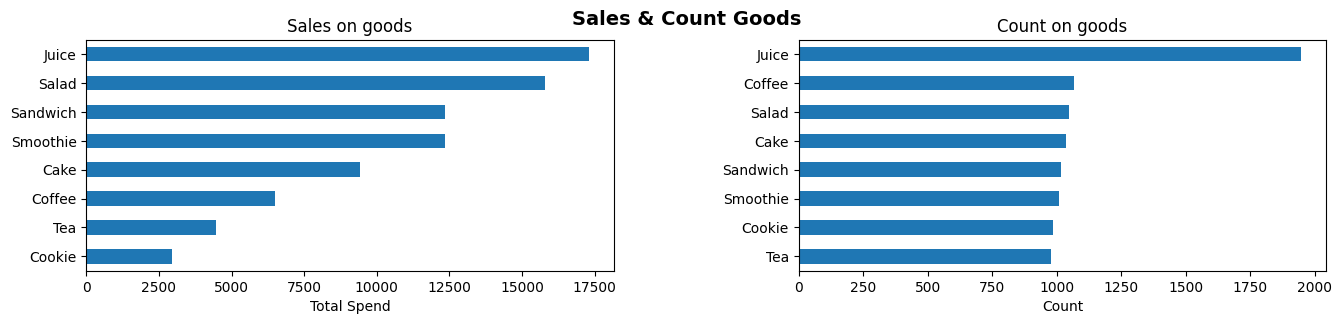

In [340]:
# Sales & Count of items
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
fig.suptitle("Sales & Count Goods", fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

#total_spent per item
ax = axes[0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Sales on goods')
ax.set_xlabel('Total Spend')
ax.set_ylabel('')

#count per item
ax = axes[1]
df['item'].value_counts().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Count on goods')
ax.set_xlabel('Count')
ax.set_ylabel('')

plt.show()

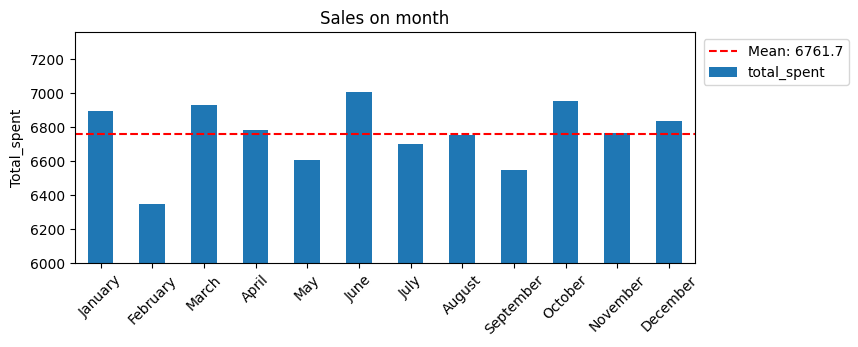

In [341]:
# Sales on month
fig = plt.figure(figsize=(8,3))
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
    ]
#display(df.groupby('month_name')['total_spent'].sum())

# Change order of indexes (we sorted a str name)
rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()])

rev_month.plot(kind='bar', rot=45)

mean_value = rev_month.mean()
std_value = rev_month.std()
std_pct = (std_value / mean_value) * 100


plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_value:.1f}')

plt.ylim(bottom=6000)

plt.title('Sales on month')
plt.xlabel('')
plt.ylabel('Total_spent')
plt.legend(bbox_to_anchor=(1.26, 1), loc='upper right')

# plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
#          bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
#          )
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')

plt.show()

In [342]:
# Шпаогалка

import calendar
print([calendar.month_name[i] for i in range(1, 13)])

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


Homework: add plot as you see

In [343]:
#save graph in order(use before plt.show())
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Saving a clean CSV for Tableau

In [344]:
# For Tableau better date format: YYYY-MM-DD
df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')

#For Tableau: bool -> str
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}") # work in Colab('data/file_name.csv')
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16
Columns: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date', 'year', 'month', 'month_name', 'weekday', 'week', 'season', 'is_weekend', 'spend_tier']
